# Notebook 03 - Modelado ML tradicional (SVM + Random Forest)

**Fase CRISP-DM:** 4. Modelado (ML tradicional)
**Target:** 3 clases universales de calidad.

## Objetivos
1. Extraer el vector handcrafted 141-D del manifest de train.
2. Tunear SVM (RBF) y Random Forest con GridSearchCV 5-fold sobre F1-macro.
3. Reportar matrices de confusion y metricas sobre val.
4. Guardar modelos en `experiments/checkpoints/` para usarlos en el notebook 05.

> Tiempo estimado: extraccion de features ~5-10 min; SVM GridSearch ~10-20 min; RF ~5 min.


In [7]:
# Setup
import sys, time
from pathlib import Path
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from tqdm import tqdm

REPO_ROOT = Path.cwd().resolve()
if REPO_ROOT.name == "notebooks":
    REPO_ROOT = REPO_ROOT.parent
sys.path.insert(0, str(REPO_ROOT))

from src.data.preprocess import load_and_preprocess_image
from src.utils.features import extract_features
from src.models.ml_models import SVMClassifier, RFClassifier
from src.evaluation.evaluate import (
    classification_report_dict, plot_confusion_matrix,
    plot_bias_matrix, accuracy_per_fruit,
)

FIG_DIR = REPO_ROOT / "outputs" / "figures" / "model_ml"
CKPT_DIR = REPO_ROOT / "experiments" / "checkpoints"
FIG_DIR.mkdir(parents=True, exist_ok=True)
CKPT_DIR.mkdir(parents=True, exist_ok=True)
print(f"Figuras: {FIG_DIR}")
print(f"Checkpoints: {CKPT_DIR}")

Figuras: C:\Users\Kevin Cifuentes\Desktop\Estudios\APO3\Proyecto\APO3_TrabajoFinal\APO3_TrabajoFinal\Apo3_ProyectoFinal\outputs\figures\model_ml
Checkpoints: C:\Users\Kevin Cifuentes\Desktop\Estudios\APO3\Proyecto\APO3_TrabajoFinal\APO3_TrabajoFinal\Apo3_ProyectoFinal\experiments\checkpoints


## 1. Cargar splits y extraer features (con cache)

In [8]:
train_df = pd.read_csv(REPO_ROOT / "data" / "processed" / "train_manifest.csv")
val_df = pd.read_csv(REPO_ROOT / "data" / "processed" / "val_manifest.csv")
test_df = pd.read_csv(REPO_ROOT / "data" / "processed" / "test_manifest.csv")
print(f"train: {len(train_df)}  val: {len(val_df)}  test: {len(test_df)}")

def extract_or_load(df, name):
    cache = REPO_ROOT / "data" / "processed" / f"features_{name}.npz"
    if cache.exists():
        print(f"  Cache: {cache.name}")
        z = np.load(cache, allow_pickle=True)
        return z["X"], z["y"], z["fruit"]
    print(f"  Extrayendo {len(df)} imagenes ...")
    X = np.stack([extract_features(load_and_preprocess_image(REPO_ROOT / p))
                  for p in tqdm(df["path"])])
    y = df["quality"].values
    fruit = df["fruit"].values
    np.savez(cache, X=X, y=y, fruit=fruit)
    return X, y, fruit

X_train, y_train, fruit_train = extract_or_load(train_df, "train")
X_val,   y_val,   fruit_val   = extract_or_load(val_df,   "val")
X_test,  y_test,  fruit_test  = extract_or_load(test_df,  "test")
print(f"\nShapes: X_train={X_train.shape}  X_val={X_val.shape}  X_test={X_test.shape}")

train: 5461  val: 1171  test: 1171
  Cache: features_train.npz
  Cache: features_val.npz
  Cache: features_test.npz

Shapes: X_train=(5461, 141)  X_val=(1171, 141)  X_test=(1171, 141)


In [9]:
# Fix: sklearn paraleliza mejor con pd.Series que con numpy object arrays
y_train = pd.Series(y_train)
y_val = pd.Series(y_val)
y_test = pd.Series(y_test)
print(f"Tipos: y_train={type(y_train).__name__}, dtype={y_train.dtype}")

Tipos: y_train=Series, dtype=str


## 2. SVM con kernel RBF + GridSearchCV

Fitting 5 folds for each of 9 candidates, totalling 45 fits


c:\Users\Kevin Cifuentes\Desktop\Estudios\APO3\Proyecto\APO3_TrabajoFinal\APO3_TrabajoFinal\Apo3_ProyectoFinal\.venv\Lib\site-packages\sklearn\svm\_base.py:239: FutureWarning: The `probability` parameter was deprecated in 1.9 and will be removed in version 1.11. Use `CalibratedClassifierCV(SVC(), ensemble=False)` instead of `SVC(probability=True)`
  warnings.warn(



[SVM] Tiempo: 0.5 min
[SVM] best_params: {'clf__C': 10.0, 'clf__gamma': 0.01}

[SVM] Val accuracy: 0.9821
[SVM] Val F1-macro: 0.9795


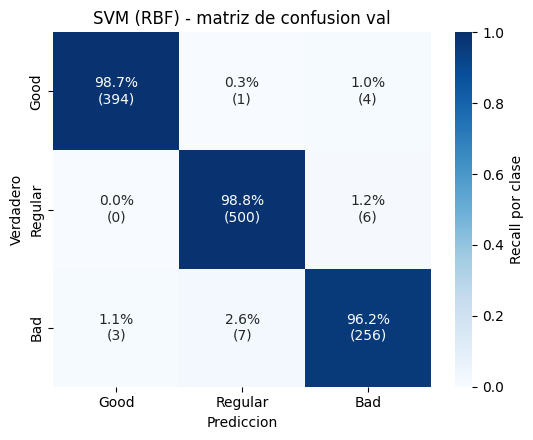

[SVM] Guardado en C:\Users\Kevin Cifuentes\Desktop\Estudios\APO3\Proyecto\APO3_TrabajoFinal\APO3_TrabajoFinal\Apo3_ProyectoFinal\experiments\checkpoints\svm_rbf.joblib


In [10]:
svm = SVMClassifier()
t0 = time.time()
svm.fit(X_train, y_train, do_grid_search=True, verbose=1)
print(f"\n[SVM] Tiempo: {(time.time()-t0)/60:.1f} min")
print(f"[SVM] best_params: {svm.best_params_}")

y_val_pred_svm = svm.predict(X_val)
rep_svm = classification_report_dict(y_val, y_val_pred_svm)
print(f"\n[SVM] Val accuracy: {rep_svm['_accuracy']:.4f}")
print(f"[SVM] Val F1-macro: {rep_svm['_f1_macro']:.4f}")
plot_confusion_matrix(y_val, y_val_pred_svm,
    title="SVM (RBF) - matriz de confusion val",
    out_path=FIG_DIR / "01_svm_cm_val.svg")
plt.show()

svm.save(CKPT_DIR / "svm_rbf.joblib")
print(f"[SVM] Guardado en {CKPT_DIR / 'svm_rbf.joblib'}")

## 3. Random Forest + GridSearchCV

Fitting 5 folds for each of 18 candidates, totalling 90 fits

[RF] Tiempo: 1.0 min
[RF] best_params: {'clf__max_depth': None, 'clf__max_features': 'sqrt', 'clf__n_estimators': 200}

[RF] Val accuracy: 0.9804
[RF] Val F1-macro: 0.9772


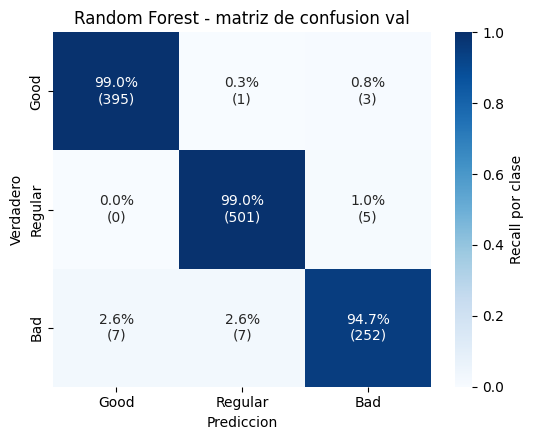

[RF] Guardado en C:\Users\Kevin Cifuentes\Desktop\Estudios\APO3\Proyecto\APO3_TrabajoFinal\APO3_TrabajoFinal\Apo3_ProyectoFinal\experiments\checkpoints\random_forest.joblib


In [11]:
rf = RFClassifier()
t0 = time.time()
rf.fit(X_train, y_train, do_grid_search=True, verbose=1)
print(f"\n[RF] Tiempo: {(time.time()-t0)/60:.1f} min")
print(f"[RF] best_params: {rf.best_params_}")

y_val_pred_rf = rf.predict(X_val)
rep_rf = classification_report_dict(y_val, y_val_pred_rf)
print(f"\n[RF] Val accuracy: {rep_rf['_accuracy']:.4f}")
print(f"[RF] Val F1-macro: {rep_rf['_f1_macro']:.4f}")
plot_confusion_matrix(y_val, y_val_pred_rf,
    title="Random Forest - matriz de confusion val",
    out_path=FIG_DIR / "02_rf_cm_val.svg")
plt.show()

rf.save(CKPT_DIR / "random_forest.joblib")
print(f"[RF] Guardado en {CKPT_DIR / 'random_forest.joblib'}")

## 4. Feature importance del Random Forest

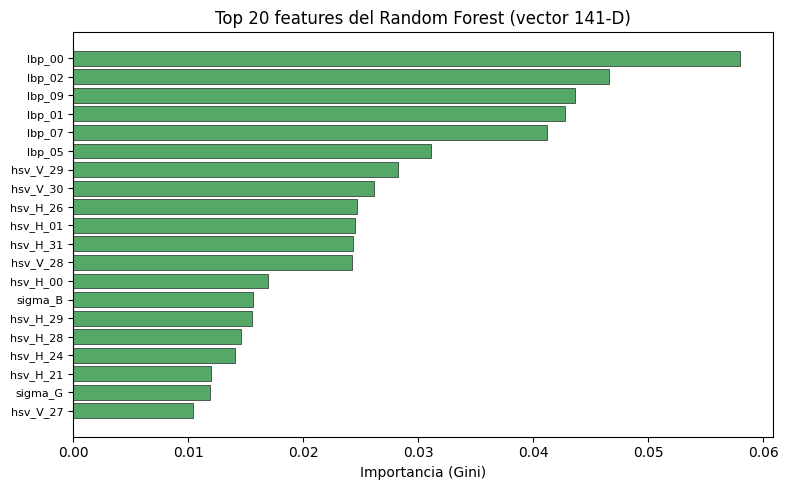

In [12]:
from src.utils.features import feature_names
imp = rf.feature_importances()
names = feature_names()
idx = np.argsort(imp)[::-1][:20]

fig, ax = plt.subplots(figsize=(8, 5))
ax.barh(range(20), imp[idx][::-1], color="#55a868", edgecolor="black", linewidth=0.4)
ax.set_yticks(range(20))
ax.set_yticklabels([names[i] for i in idx[::-1]], fontsize=8)
ax.set_xlabel("Importancia (Gini)")
ax.set_title("Top 20 features del Random Forest (vector 141-D)")
plt.tight_layout()
plt.savefig(FIG_DIR / "03_rf_feature_importance.svg")
plt.show()

## 5. Analisis de sesgo en val (matriz 6x6 por fruta)

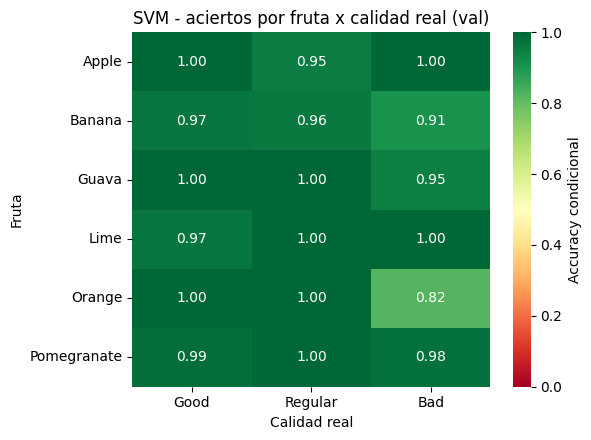


Accuracy condicional por fruta (SVM, val):
      fruit   n  accuracy  f1_macro
       Lime 160  0.993750  0.992800
      Guava 119  0.991597  0.989055
Pomegranate 497  0.987928  0.989176
      Apple 128  0.976562  0.971718
     Orange 124  0.975806  0.961290
     Banana 143  0.951049  0.946107


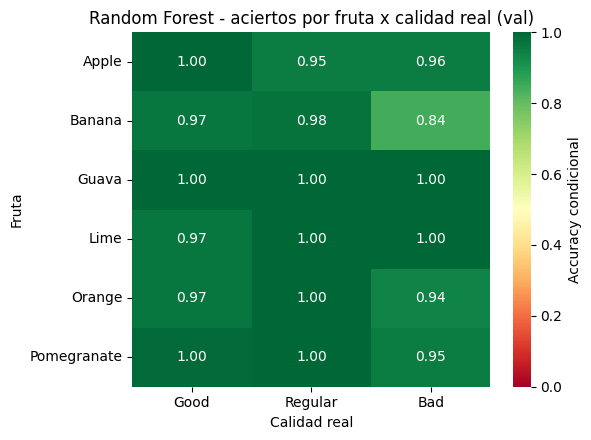


Accuracy condicional por fruta (RF, val):
      fruit   n  accuracy  f1_macro
      Guava 119  1.000000  1.000000
       Lime 160  0.993750  0.992800
Pomegranate 497  0.983903  0.985458
     Orange 124  0.983871  0.972749
      Apple 128  0.968750  0.961806
     Banana 143  0.944056  0.937198


In [13]:
# SVM
plot_bias_matrix(y_val, y_val_pred_svm, fruit_val,
                 title="SVM - aciertos por fruta x calidad real (val)",
                 out_path=FIG_DIR / "04_svm_bias_matrix.svg")
plt.show()
print("\nAccuracy condicional por fruta (SVM, val):")
print(accuracy_per_fruit(y_val, y_val_pred_svm, fruit_val).to_string(index=False))

# RF
plot_bias_matrix(y_val, y_val_pred_rf, fruit_val,
                 title="Random Forest - aciertos por fruta x calidad real (val)",
                 out_path=FIG_DIR / "05_rf_bias_matrix.svg")
plt.show()
print("\nAccuracy condicional por fruta (RF, val):")
print(accuracy_per_fruit(y_val, y_val_pred_rf, fruit_val).to_string(index=False))

## Siguiente paso

Notebook 04: CNN desde cero. Notebook 05: evaluacion comparativa sobre **test** (no val) con los 3 modelos.